In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score, log_loss

from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, ElasticNet
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier, VotingRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from tqdm import tqdm 
import warnings
warnings.filterwarnings("ignore")

In [2]:
cancer = pd.read_csv('D:/Machine_Learning/Cases/Wisconsin/BreastCancer.csv')
cancer

,Code,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
0,61634,5,4,3,1,2,2,2,3,1,Benign
1,63375,9,1,2,6,4,10,7,7,2,Malignant
2,76389,10,4,7,2,2,8,6,1,1,Malignant
3,95719,6,10,10,10,8,10,7,10,7,Malignant
4,128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
694,1369821,10,10,10,10,5,10,10,10,7,Malignant
695,1371026,5,10,10,10,4,10,5,6,3,Malignant
696,1371920,5,1,1,1,2,1,3,2,1,Benign
697,8233704,4,1,1,1,1,1,2,1,1,Benign


In [5]:
X , y = cancer.drop(['Code','Class'], axis=1), cancer['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26, stratify= y)

In [6]:
features = [2,3,4,5,6,7]
scores = []
for f in tqdm (features):
    for n in [25, 50, 75, 100, 125]:
        rf = RandomForestClassifier(random_state= 26, max_features = f, n_estimators = n)
        rf.fit(X_train, y_train)
        y_pred_prob = rf.predict_proba(X_test)
        scores.append([f, n, log_loss(y_test, y_pred_prob)])
df_scores = pd.DataFrame(scores, columns = ['max_features', 'n_est','score'])
df_scores.sort_values('score')

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:04<00:00,  1.36it/s]


,max_features,n_est,score
20,6,25,0.090337
22,6,75,0.091812
21,6,50,0.092632
1,2,50,0.092803
0,2,25,0.093055
2,2,75,0.094992
24,6,125,0.095253
23,6,100,0.095366
12,4,75,0.095764
3,2,100,0.096179


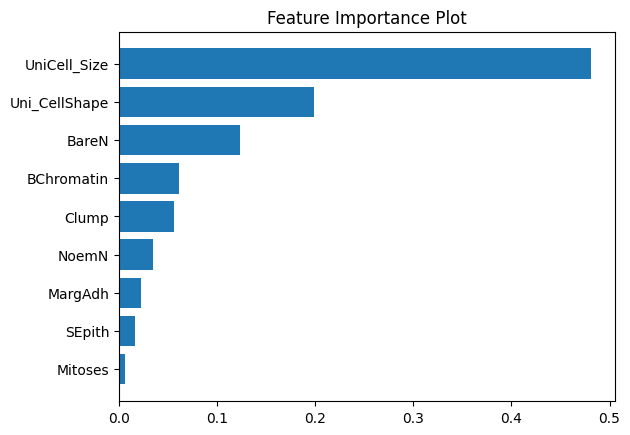

In [11]:
bm =  RandomForestClassifier(random_state= 26, max_features = 6, n_estimators =25)
bm.fit(X,y)

df_imp = pd.DataFrame({'feature':X.columns, 'importance':bm.feature_importances_})
df_imp.sort_values('importance',inplace = True)
plt.barh(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()

### Random Forest classification on HR :

In [ ]:
features = [2,3,4,5,6,7,8,9]